# 03 ML 비교 — B1 대 Ridge·KNN·랜덤포레스트·XGBoost

목적: 기준선 B1(공시가격 × 실거래/공시 비율)보다 나은 모델이 있는지, 있다면 무엇인지 **같은 최종 검증 건물 632개**에서 비교하고 고른다.
설계·선정 기준·결정은 `docs/의사결정/1007_10_ML_비교.md`, 실험 코드는 `src/ml.py`·`src/run_ml_compare.py`.

**이 노트북은 저장된 실험 결과(`outputs/ml_*.csv`)만 읽는다.** 그리드서치·학습을 다시 하지 않는다.

| 계열 | 파이프라인 |
|---|---|
| Ridge | 결측 채움 → 표준화 → 선형 회귀(규제) |
| KNN | 결측 채움 → 표준화 → 비슷한 거래 k개 평균 |
| RF | 랜덤포레스트(결측 그대로) |
| XGB | XGBoost(결측 그대로) |

| 방식 | 목표값 |
|---|---|
| 직접 | log(기준일 ㎡당 가격) — 헤도닉 변수 17개 |
| 잔차 | log(기준일 실거래가 ÷ B1 추정) — 헤도닉 + B1 근거 6개 |
| 평균 | 직접 × 잔차의 기하평균 |

| 상황 | 뜻 |
|---|---|
| A | 처음 보는 건물(검증 건물 거래 모두 제외) |
| B | 같은 건물 앞선 거래가 있음(실제 입력에 가장 가까움) |
| T | 시점 밖: 2025-08까지 거래로 만든 모델로 그 뒤 1년 거래를 맞힘(새 데이터·가격 변동에 버티는지) |


In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from avm import SGG_NAME
from sklearn import set_config
from ml import make_pipeline, FEATURES, GRIDS
set_config(display="text")  # HTML 도식은 Windows 기본 인코딩에서 읽기 오류
plt.rcParams["font.family"] = "Malgun Gothic"; plt.rcParams["axes.unicode_minus"] = False
OUT = ROOT / "outputs"
pred = pd.read_csv(OUT / "ml_predictions.csv", dtype={"pnu": str, "sgg_cd": str})
met = pd.read_csv(OUT / "ml_metrics.csv")
ORDER = ["B1"] + [f"{f}-{w}" for f in ["Ridge", "KNN", "RF", "XGB"] for w in ["직접", "잔차", "평균"]]
display(make_pipeline("Ridge", FEATURES["잔차"])); display(make_pipeline("XGB", FEATURES["잔차"]))

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['log_public_m2', 'log_area',
                                                   'floor', 'is_basement',
                                                   'rel_floor', 'is_top_floor',
                                                   'age', 'elevator',
                                                   'grnd_flr', 'log_hhld',
                                                   'parking_per_hhld',
                                                   'log_station', 'log_land',
                                                   'lon', 'lat', 'gangnam',
                                                   'hwagok', 'b1_ratio',
                                                   'area_ratio', 'area_sd',
                                                   'b_n', 'b_gap', 'b_sd'])])),
                ('impute',
                 SimpleImputer(add_indicat

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['log_public_m2', 'log_area',
                                                   'floor', 'is_basement',
                                                   'rel_floor', 'is_top_floor',
                                                   'age', 'elevator',
                                                   'grnd_flr', 'log_hhld',
                                                   'parking_per_hhld',
                                                   'log_station', 'log_land',
                                                   'lon', 'lat', 'gangnam',
                                                   'hwagok', 'b1_ratio',
                                                   'area_ratio', 'area_sd',
                                                   'b_n', 'b_gap', 'b_sd'])])),
                ('xgb',
                 XGBRegressor(ba...
         

## 1. 그리드서치 (학습 세트 안 건물 단위 GroupKFold(5), MAE = log 오차 절댓값 평균)

계열·방식마다 최적 조합. CV 오차는 목표값이 다른 직접·잔차끼리 직접 비교하지 않는다

In [2]:
cv = pd.read_csv(OUT / "ml_cv_results.csv")
print("그리드:", GRIDS)
cv.assign(CV_MAE=-cv.mean_test_score).query("rank_test_score == 1").pivot_table(
    index=["계열", "방식"], columns="상황", values="CV_MAE").round(4)

그리드: {'Ridge': {'ridge__alpha': [0.1, 1, 10, 100]}, 'KNN': {'knn__n_neighbors': [5, 10, 20, 40], 'knn__weights': ['uniform', 'distance']}, 'RF': {'rf__min_samples_leaf': [2, 5, 20], 'rf__max_features': [0.33, 0.6]}, 'XGB': {'xgb__max_depth': [3, 5, 7, 9], 'xgb__n_estimators': [300, 800, 1500], 'xgb__min_child_weight': [5, 20]}}


상황             A       B       T
계열    방식                        
KNN   잔차  0.1140  0.1142  0.1078
      직접  0.1591  0.1573  0.1527
RF    잔차  0.1105  0.1109  0.1053
      직접  0.1300  0.1291  0.1239
Ridge 잔차  0.1165  0.1164  0.1101
      직접  0.1499  0.1489  0.1451
XGB   잔차  0.1107  0.1108  0.1057
      직접  0.1295  0.1283  0.1236

In [3]:
cv.query("rank_test_score == 1").pivot_table(index=["계열", "방식"], columns="상황", values="params", aggfunc="first")

상황                                                        A  \
계열    방식                                                      
KNN   잔차  {'knn__n_neighbors': 40, 'knn__weights': 'dist...   
      직접  {'knn__n_neighbors': 20, 'knn__weights': 'dist...   
RF    잔차  {'rf__max_features': 0.33, 'rf__min_samples_le...   
      직접  {'rf__max_features': 0.33, 'rf__min_samples_le...   
Ridge 잔차                              {'ridge__alpha': 100}   
      직접                              {'ridge__alpha': 0.1}   
XGB   잔차  {'xgb__max_depth': 7, 'xgb__min_child_weight':...   
      직접  {'xgb__max_depth': 5, 'xgb__min_child_weight':...   

상황                                                        B  \
계열    방식                                                      
KNN   잔차  {'knn__n_neighbors': 40, 'knn__weights': 'dist...   
      직접  {'knn__n_neighbors': 20, 'knn__weights': 'dist...   
RF    잔차  {'rf__max_features': 0.33, 'rf__min_samples_le...   
      직접  {'rf__max_features': 0.33, 'rf__min_samples_le...   
Ridge 잔차                              {'ridge__alpha': 100}   
      직접                              {'ridge__alpha': 0.1}   
XGB   잔차  {'xgb__max_depth': 9, 'xgb__min_child_weight':...   
      직접  {'xgb__max_depth': 5, 'xgb__min_child_weight':...   

상황                                                        T  
계열    방식                                                     
KNN   잔차  {'knn__n_neighbors': 40, 'knn__weights': 'dist...  
      직접  {'knn__n_neighbors': 20, 'knn__weights': 'dist...  
RF    잔차  {'rf__max_features': 0.33, 'rf__min_samples_le...  
      직접  {'rf__max_features': 0.33, 'rf__min_samples_le...  
Ridge 잔차                              {'ridge__alpha': 100}  
      직접                              {'ridge__alpha': 0.1}  
XGB   잔차  {'xgb__max_depth': 7, 'xgb__min_child_weight':...  
      직접  {'xgb__max_depth': 5, 'xgb__min_child_weight':...

## 2. 최종 검증 지표

In [4]:
t = met.pivot(index="모델", columns="상황", values=["±20%", "중앙값APE", "MAPE"]).reindex(ORDER)
t.style.format("{:.1%}").highlight_max(subset=[c for c in t.columns if c[0] == "±20%"], color="#cfe8cf").highlight_min(
    subset=[c for c in t.columns if c[0] != "±20%"], color="#cfe8cf")

## 3. 선정 기준에 따른 순위

상황마다 ±20% 적중률·MAPE·중앙값 오차율 순위의 평균. 기준(1007_10 §3)은 결과를 보기 전에 정했다 — 세 상황 모두에서 상위권인지(가장 나쁜 순위)를 함께 본다

In [5]:
r = met.assign(r20=met.groupby("상황")["±20%"].rank(ascending=False), rmape=met.groupby("상황")["MAPE"].rank(),
               rmed=met.groupby("상황")["중앙값APE"].rank())
r["순위"] = r[["r20", "rmape", "rmed"]].mean(axis=1)
rank = r.pivot(index="모델", columns="상황", values="순위")
rank["평균 순위"] = rank.mean(axis=1); rank["가장 나쁜 순위"] = rank[list("ABT")].max(axis=1)
rank.sort_values("평균 순위").round(1)

상황,A,B,T,평균 순위,가장 나쁜 순위
모델,,,,,
XGB-평균,2.3,2.0,1.2,1.8,2.3
RF-평균,4.3,3.0,3.5,3.6,4.3
XGB-잔차,4.7,3.7,3.3,3.9,4.7
XGB-직접,1.7,5.3,5.2,4.1,5.3
RF-잔차,7.0,2.7,3.8,4.5,7.0
RF-직접,2.0,5.7,7.3,5.0,7.3
KNN-평균,6.3,5.7,5.7,5.9,6.3
KNN-잔차,8.7,8.0,6.5,7.7,8.7
Ridge-잔차,8.7,9.2,8.5,8.8,9.2


## 4. 차이가 우연이 아닌지 — 짝 비교 부트스트랩

같은 632건에서 건물을 2,000번 재표본해 차이의 95% 구간을 낸다. 구간이 0을 넘지 않으면 우연이 아니라고 본다(APE 차이는 음수, ±20% 차이는 양수가 좋음)

In [6]:
rng = np.random.default_rng(0)
PAIRS = [("XGB-평균", "B1"), ("XGB-평균", "RF-평균"), ("XGB-평균", "XGB-잔차"), ("XGB-평균", "XGB-직접"),
         ("XGB-평균", "RF-잔차"), ("XGB-평균", "KNN-평균"), ("XGB-평균", "Ridge-잔차")]
fmt = lambda v, d: f"{v:+.1%} [{np.percentile(d, 2.5):+.1%}, {np.percentile(d, 97.5):+.1%}]"
rows = []
for sc in "ABT":
    w = pred[pred.상황 == sc].pivot_table(index="pnu", columns="모델", values="ape")
    idx = [rng.integers(0, len(w), len(w)) for _ in range(2000)]
    for x, y in PAIRS:
        a, b = w[x].to_numpy(), w[y].to_numpy()
        rows.append({"상황": sc, "비교": f"{x} − {y}",
                     "중앙값APE": fmt(np.median(a) - np.median(b), [np.median(a[i]) - np.median(b[i]) for i in idx]),
                     "MAPE": fmt(a.mean() - b.mean(), [a[i].mean() - b[i].mean() for i in idx]),
                     "±20%": fmt((a <= .2).mean() - (b <= .2).mean(), [(a[i] <= .2).mean() - (b[i] <= .2).mean() for i in idx])})
pd.DataFrame(rows).set_index(["상황", "비교"])

중앙값APE                  MAPE  \
상황 비교                                                              
A  XGB-평균 − B1        -1.7% [-2.5%, -0.7%]  -1.3% [-1.8%, -0.9%]   
   XGB-평균 − RF-평균     -0.7% [-1.2%, +0.1%]  -0.1% [-0.3%, +0.1%]   
   XGB-평균 − XGB-잔차    -0.9% [-1.3%, -0.0%]  -0.4% [-0.6%, -0.2%]   
   XGB-평균 − XGB-직접    +0.3% [-0.2%, +1.0%]  +0.3% [+0.1%, +0.5%]   
   XGB-평균 − RF-잔차     -1.2% [-1.8%, -0.3%]  -0.4% [-0.7%, -0.2%]   
   XGB-평균 − KNN-평균    -0.9% [-1.6%, +0.0%]  -0.7% [-1.1%, -0.2%]   
   XGB-평균 − Ridge-잔차  -1.5% [-2.2%, -0.4%]  -1.0% [-1.3%, -0.6%]   
B  XGB-평균 − B1        -1.7% [-2.3%, -0.8%]  -1.2% [-1.6%, -0.7%]   
   XGB-평균 − RF-평균     -0.4% [-1.0%, +0.2%]  +0.1% [-0.2%, +0.3%]   
   XGB-평균 − XGB-잔차    +0.1% [-0.4%, +0.6%]  -0.1% [-0.3%, +0.2%]   
   XGB-평균 − XGB-직접    -0.1% [-0.8%, +0.4%]  -0.4% [-0.6%, -0.1%]   
   XGB-평균 − RF-잔차     -0.3% [-0.8%, +0.3%]  -0.0% [-0.3%, +0.3%]   
   XGB-평균 − KNN-평균    -0.9% [-1.8%, -0.1%]  -0.5% [-0.9%, -0.1%]   
   XGB-평균 − Ridge-잔차  -1.5% [-2.4%, -0.7%]  -1.1% [-1.5%, -0.7%]   
T  XGB-평균 − B1        -1.0% [-2.0%, -0.2%]  -0.8% [-1.2%, -0.4%]   
   XGB-평균 − RF-평균     -0.4% [-1.0%, +0.2%]  -0.1% [-0.3%, +0.1%]   
   XGB-평균 − XGB-잔차    -0.2% [-0.6%, +0.6%]  -0.1% [-0.3%, +0.1%]   
   XGB-평균 − XGB-직접    -0.2% [-0.8%, +0.4%]  -0.2% [-0.4%, -0.0%]   
   XGB-평균 − RF-잔차     -0.3% [-0.9%, +0.4%]  -0.1% [-0.3%, +0.2%]   
   XGB-평균 − KNN-평균    -0.4% [-1.2%, +0.5%]  -0.6% [-1.0%, -0.2%]   
   XGB-평균 − Ridge-잔차  -0.8% [-1.8%, -0.0%]  -0.6% [-1.0%, -0.3%]   

                                      ±20%  
상황 비교                                       
A  XGB-평균 − B1        +4.3% [+1.9%, +6.5%]  
   XGB-평균 − RF-평균     +1.7% [+0.2%, +3.2%]  
   XGB-평균 − XGB-잔차    +1.6% [+0.2%, +3.0%]  
   XGB-평균 − XGB-직접    +0.8% [-0.6%, +2.2%]  
   XGB-평균 − RF-잔차     +2.8% [+0.9%, +4.6%]  
   XGB-평균 − KNN-평균    +2.1% [-0.2%, +4.3%]  
   XGB-평균 − Ridge-잔차  +3.6% [+1.6%, +5.7%]  
B  XGB-평균 − B1        +4.9% [+2.4%, +7.6%]  
   XGB-평균 − RF-평균     +1.4% [-0.5%, +3.3%]  
   XGB-평균 − XGB-잔차    +2.4% [+0.5%, +4.4%]  
   XGB-평균 − XGB-직접    +2.5% [+0.8%, +4.3%]  
   XGB-평균 − RF-잔차     -0.2% [-2.1%, +1.9%]  
   XGB-평균 − KNN-평균    +1.6% [-0.8%, +4.3%]  
   XGB-평균 − Ridge-잔차  +4.9% [+2.5%, +7.4%]  
T  XGB-평균 − B1        +2.4% [+0.2%, +4.6%]  
   XGB-평균 − RF-평균     +0.0% [-1.3%, +1.4%]  
   XGB-평균 − XGB-잔차    +1.3% [-0.3%, +2.8%]  
   XGB-평균 − XGB-직접    +1.4% [+0.0%, +3.0%]  
   XGB-평균 − RF-잔차     +1.1% [-0.8%, +2.8%]  
   XGB-평균 − KNN-평균    +0.6% [-1.6%, +2.8%]  
   XGB-평균 − Ridge-잔차  +1.4% [-0.8%, +3.6%]

## 5. 권역별·근거별 중앙값 오차율 (B1 대 상위 후보)

In [7]:
top = ["B1", "RF-평균", "XGB-잔차", "XGB-직접", "XGB-평균"]
p = pred[pred.모델.isin(top)].assign(권역=lambda d: d.sgg_cd.map(SGG_NAME))
display(p.pivot_table(index=["상황", "권역"], columns="모델", values="ape", aggfunc="median")[top].style.format("{:.1%}"))
n = p[p.모델 == "B1"].groupby(["상황", "tier"]).size().rename("n")
p.pivot_table(index=["상황", "tier"], columns="모델", values="ape", aggfunc="median")[top].join(n).style.format(
    {m: "{:.1%}" for m in top})

## 6. 시간이 지나면 — 상황 T의 치우침

log(추정/실제)의 중앙값. 음수면 낮게 추정. T는 학습 마감(2025-08) 뒤 오른 가격이 그대로 오차가 된다

상황,A,B,T
모델,,,
B1,-0.8%,-0.8%,-3.5%
Ridge-직접,+0.6%,+0.6%,-2.3%
Ridge-잔차,-1.4%,+0.2%,-2.1%
Ridge-평균,-0.5%,+0.7%,-2.4%
KNN-직접,-0.9%,-1.3%,-4.6%
KNN-잔차,-1.2%,-0.6%,-3.5%
KNN-평균,-1.3%,-1.1%,-4.5%
RF-직접,-1.0%,-1.5%,-4.1%
RF-잔차,-1.5%,-0.7%,-3.6%


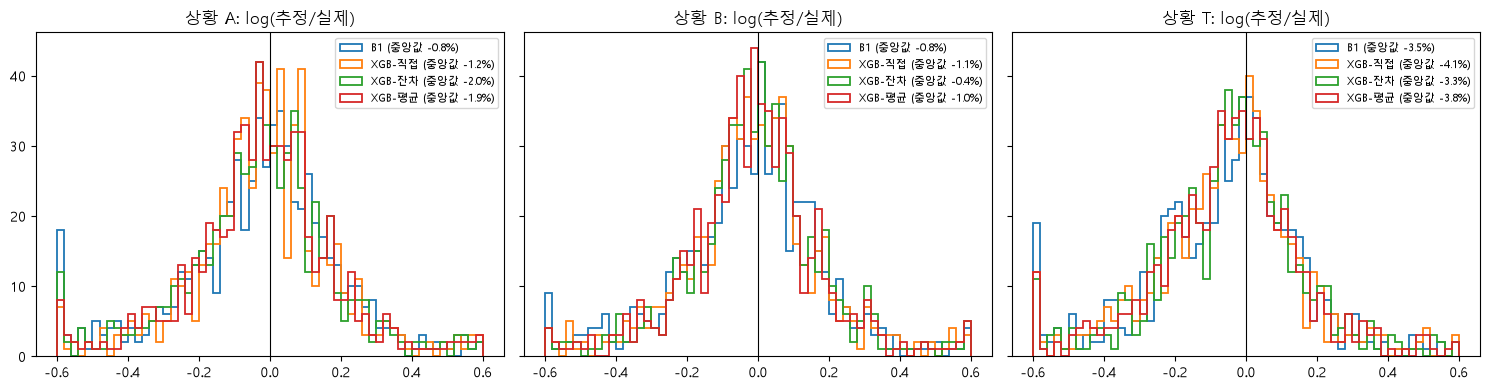

In [8]:
bias = met.pivot(index="모델", columns="상황", values="log오차중앙값").reindex(ORDER)
display(bias.style.format("{:+.1%}"))
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, sc in zip(axes, "ABT"):
    for name in ["B1", "XGB-직접", "XGB-잔차", "XGB-평균"]:
        e = pred[(pred.상황 == sc) & (pred.모델 == name)].log_err
        ax.hist(e.clip(-0.6, 0.6), bins=60, histtype="step", lw=1.3, label=f"{name} (중앙값 {e.median():+.1%})")
    ax.axvline(0, color="k", lw=0.8); ax.set_title(f"상황 {sc}: log(추정/실제)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 7. 변수 중요도 (XGBoost gain 비중, 상황 B)

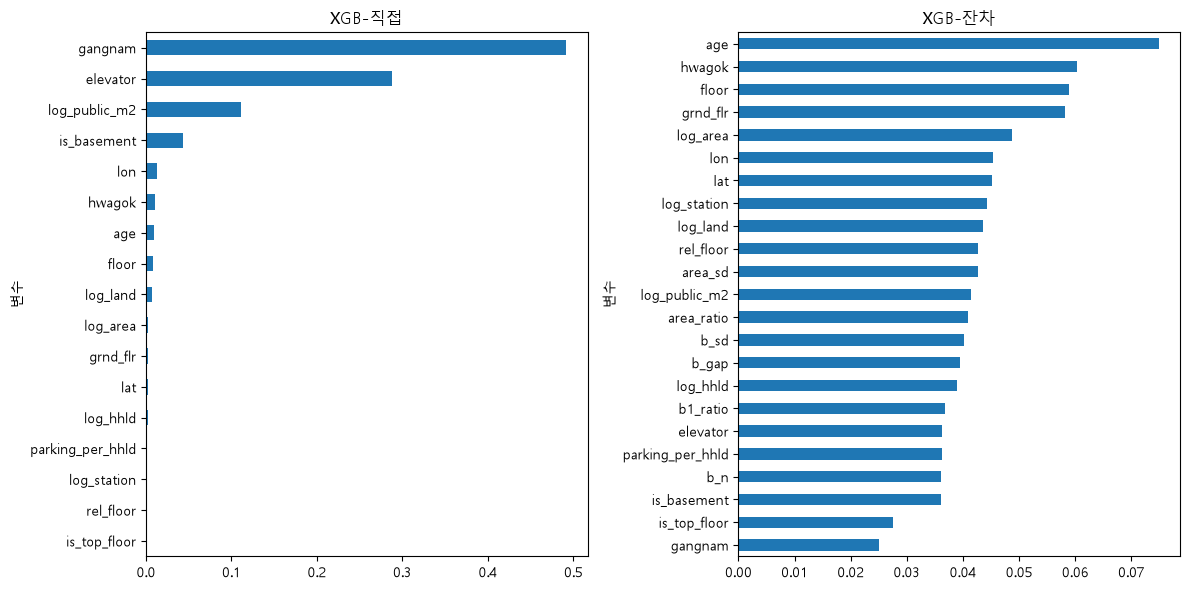

In [9]:
imp = pd.read_csv(OUT / "ml_importance.csv")
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
for ax, way in zip(axes, ["직접", "잔차"]):
    s = imp.query("계열 == 'XGB' and 상황 == 'B' and 방식 == @way").set_index("변수")["중요도"].sort_values()
    s.plot.barh(ax=ax, title=f"XGB-{way}")
plt.tight_layout(); plt.show()

## 8. 결론

- 최종 모델: **XGB-평균**(XGBoost 직접 × XGBoost 잔차의 기하평균). 평균 순위·가장 나쁜 순위 모두 1위, 세 상황 모두에서 B1보다 확실히 낫다
- 수치·판단·한계는 `docs/의사결정/1007_10_ML_비교.md` §4～5